# Implémentation de la méthode CDF-t

## Importation des bibliothèques

In [1]:
from functions import (  # noqa: E402
    csv_to_pd_univ, 
    cdf_t_univ, 
    plot_distributions,
    comparer_distributions,
    plot_distributions_univ_norm,
    extract_month_data,
)

import numpy as np
import pandas as pd
from scipy import stats
#import SBCK # noqa: E402
#import pandas as pd

## Implémentation CDF-t univariée (température)

### Correction CMIP6 sur les observations

#### Comparaison valeurs réelles et valeurs corrigées

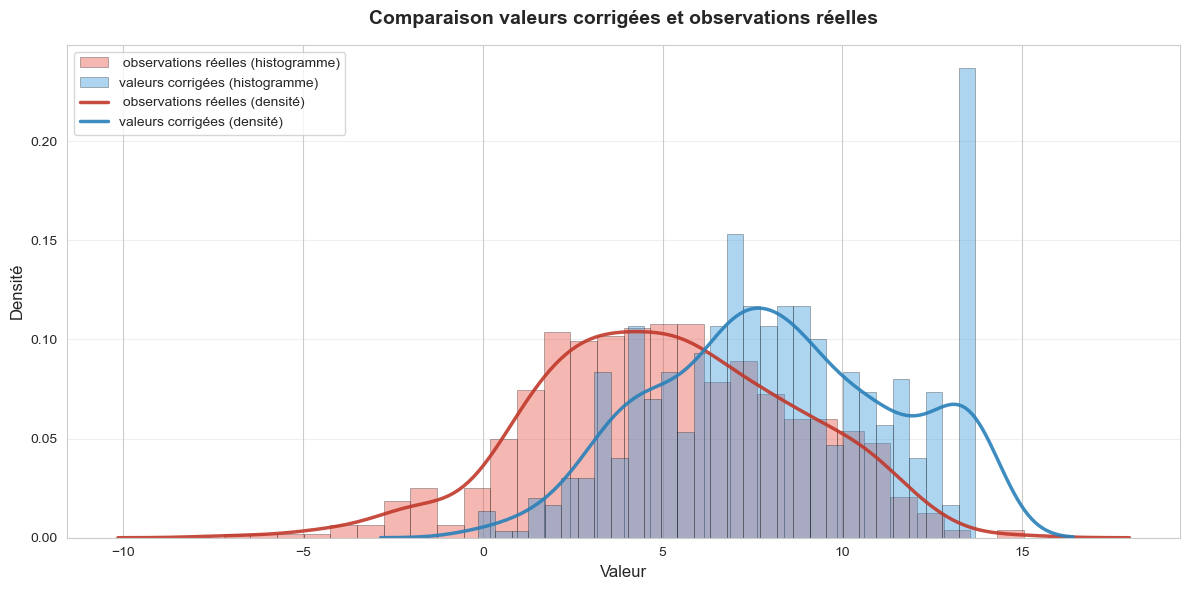

In [3]:
month = 12  # Variable mois définie au début (ex: 12 pour Décembre)
var_name = "tas"

path_CMIP6_hist = "data/CMIP6_historical.csv"
path_CMIP6_fut = "data/CMIP6_ssp585.csv"
path_obs = "data/obs.csv"
path_EUROCORDEX = "data/eurocordex_rcp85.csv"
path_EUROCORDEX_hist = "data/eurocordex_historical.csv"



#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(path_CMIP6_hist, month, var_name, years=(1995, 2014))
CMIP6_futur = csv_to_pd_univ(path_CMIP6_fut, month, var_name, years=(2080, 2100))
obs_hist = csv_to_pd_univ(path_obs, month, var_name, years=(1995, 2014))
obs_futur = csv_to_pd_univ(path_EUROCORDEX, month, "tas", years = (2080,2100))
Eurocordex_hist = csv_to_pd_univ(path_EUROCORDEX_hist, month, "tas", years = (1995,2014))


#Correction des valeurs futures du modèle par CDF-t
_, modele_futur_corrige = cdf_t_univ(CMIP6_hist, obs_hist, CMIP6_futur)

#Représentation graphique
plot_distributions((obs_futur, modele_futur_corrige), "Comparaison valeurs corrigées et observations réelles", ("observations réelles","valeurs corrigées"),)

#### Comparaison passé/futur dans le modèle et dans les observations

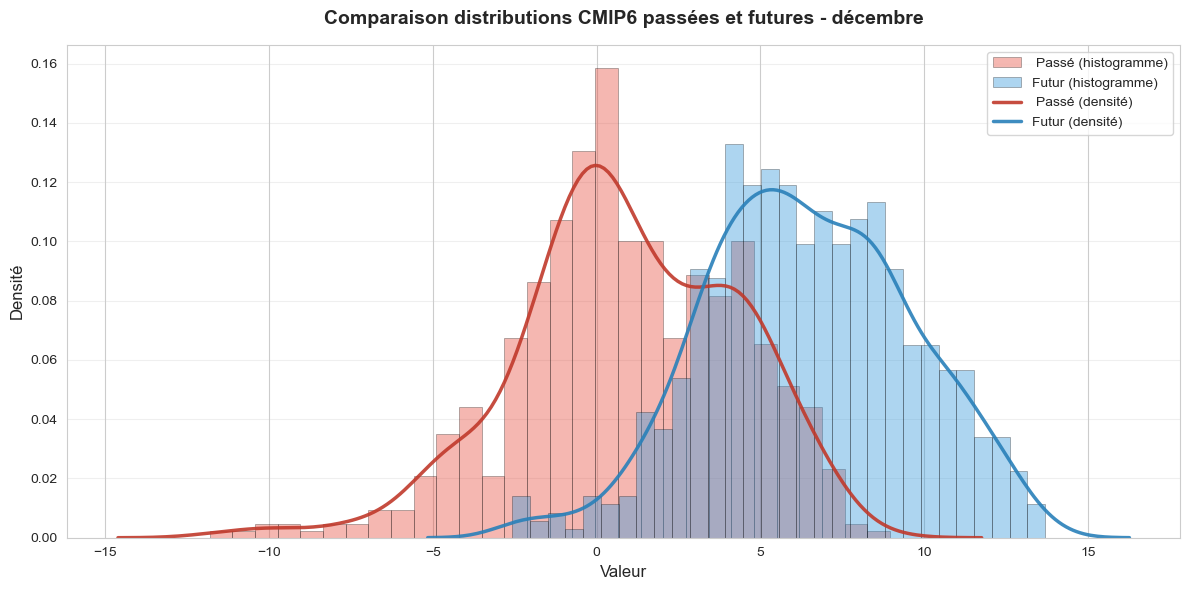

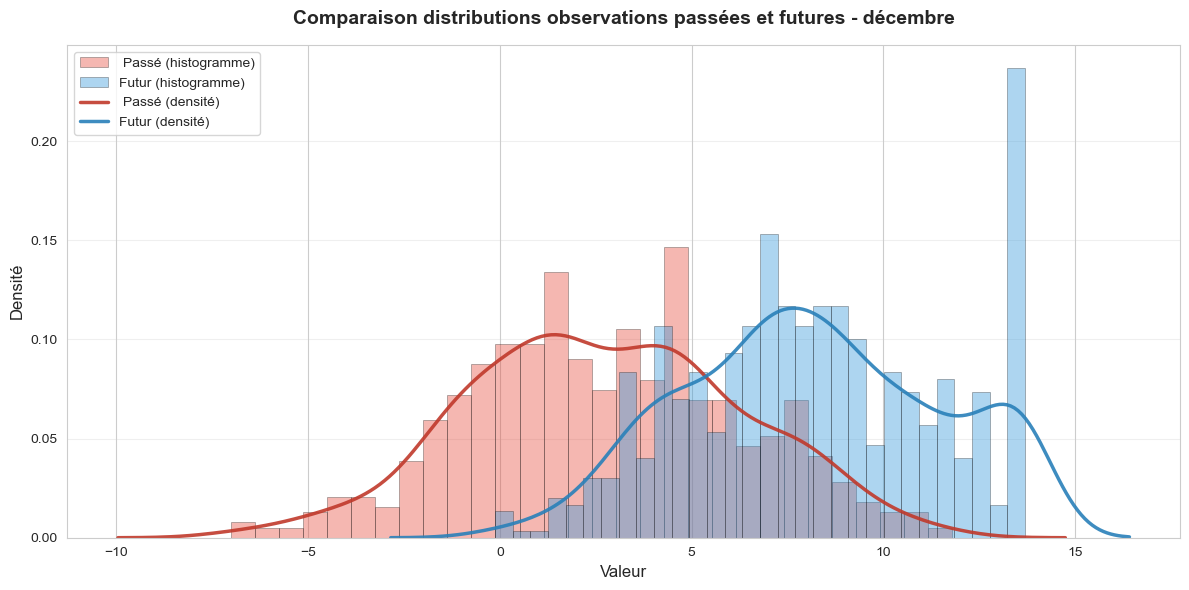

In [4]:
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentations graphiques
plot_distributions((CMIP6_hist, CMIP6_futur),"Comparaison distributions CMIP6 passées et futures - décembre",("Passé","Futur"))
plot_distributions((obs_hist,modele_futur_corrige),"Comparaison distributions observations passées et futures - décembre",("Passé","Futur") )

#### Comparaison modèle/observations dans le passé et dans le futur (avec valeurs corrigées)

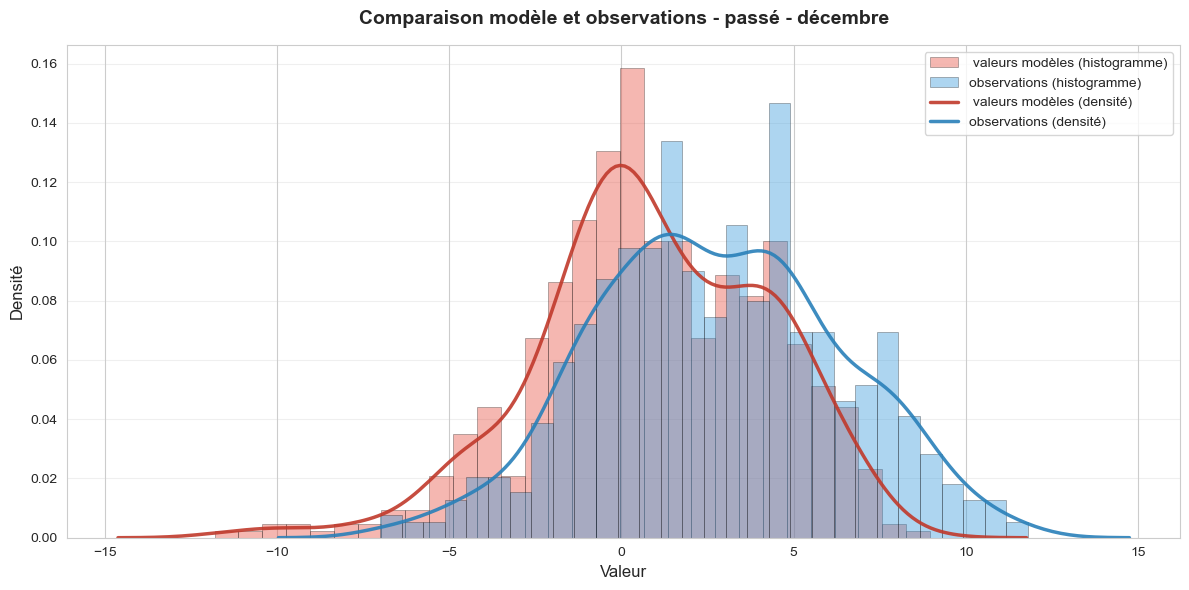

In [5]:
#Représentation graphique
plot_distributions((CMIP6_hist, obs_hist),
                           "Comparaison modèle et observations - passé - décembre",
                           ("valeurs modèles","observations"))

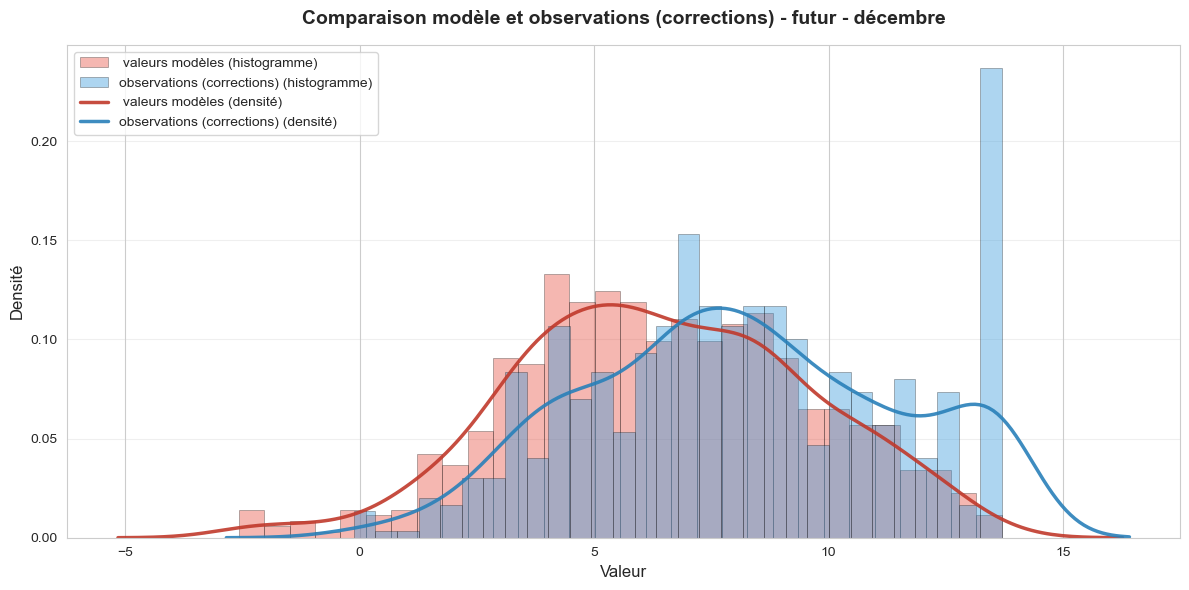

In [ ]:
#Comparaison futur 

#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ(path_CMIP6_hist, 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ(path_CMIP6_fut, 12, "tas", years= (2015,2100))
obs_hist = csv_to_pd_univ(path_obs, 12, "tas", years = (1982,2014))

#Correction des valeurs futures du modèle par CDF-t
_ ,modele_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

#Représentation graphique
plot_distributions((CMIP6_futur, modele_futur_corrige),
                           "Comparaison modèle et observations (corrections) - futur - décembre",
                           ("valeurs modèles","observations (corrections)"))

Test avec EUROCORDEX pour vérifier

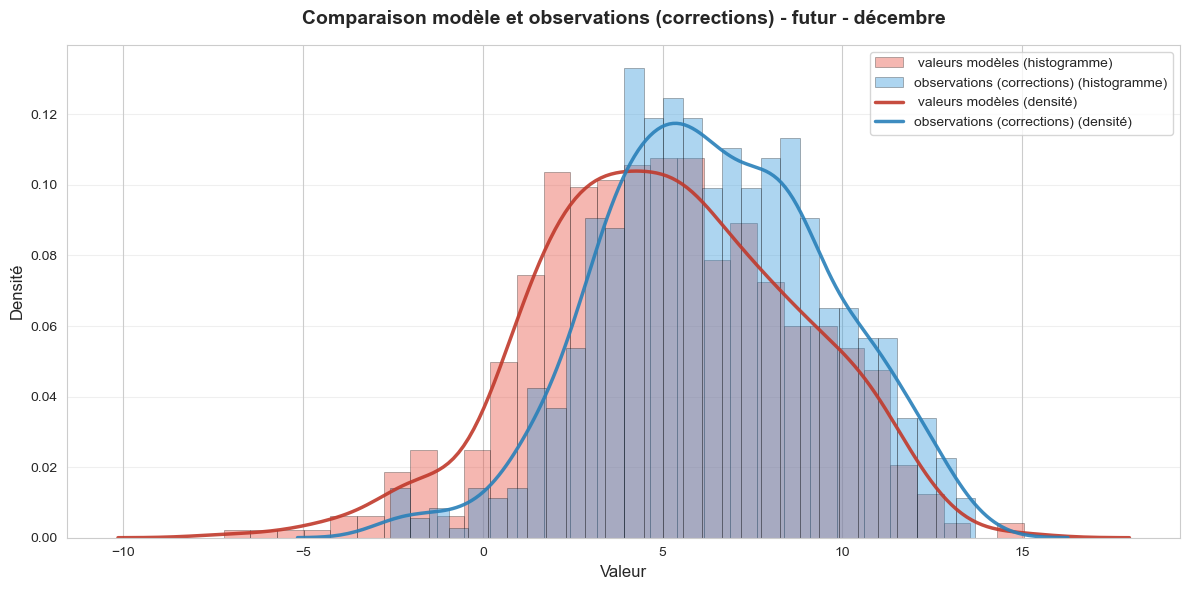

"\nplot_cdf_t(\n    EUROCORDEX_mois_tas,  # brut\n    mod_hist_corr,         # CMIP5 historique corrigé\n    obs_mois[1]['tas'],    # observations\n    fut_corr               # CMIP5 futur corrigé\n)\n"

In [9]:
_ ,test_futur_corrige  = cdf_t_univ(CMIP6_hist,obs_hist,CMIP6_futur) 

plot_distributions((obs_futur, test_futur_corrige),
                           "Comparaison modèle et observations (corrections) - futur - décembre",
                           ("valeurs modèles","observations (corrections)"))

"""
plot_cdf_t(
    EUROCORDEX_mois_tas,  # brut
    mod_hist_corr,         # CMIP5 historique corrigé
    obs_mois[1]['tas'],    # observations
    fut_corr               # CMIP5 futur corrigé
)
"""


### Cas gaussien

Paramètres estimés (MLE) :
CMIP6_hist : μ=0.55, σ=3.67
CMIP6_futur : μ=3.48, σ=4.36
obs_hist : μ=2.86, σ=3.88

Paramètres de la loi X :
μ_X = 6.22
σ_X = 4.61


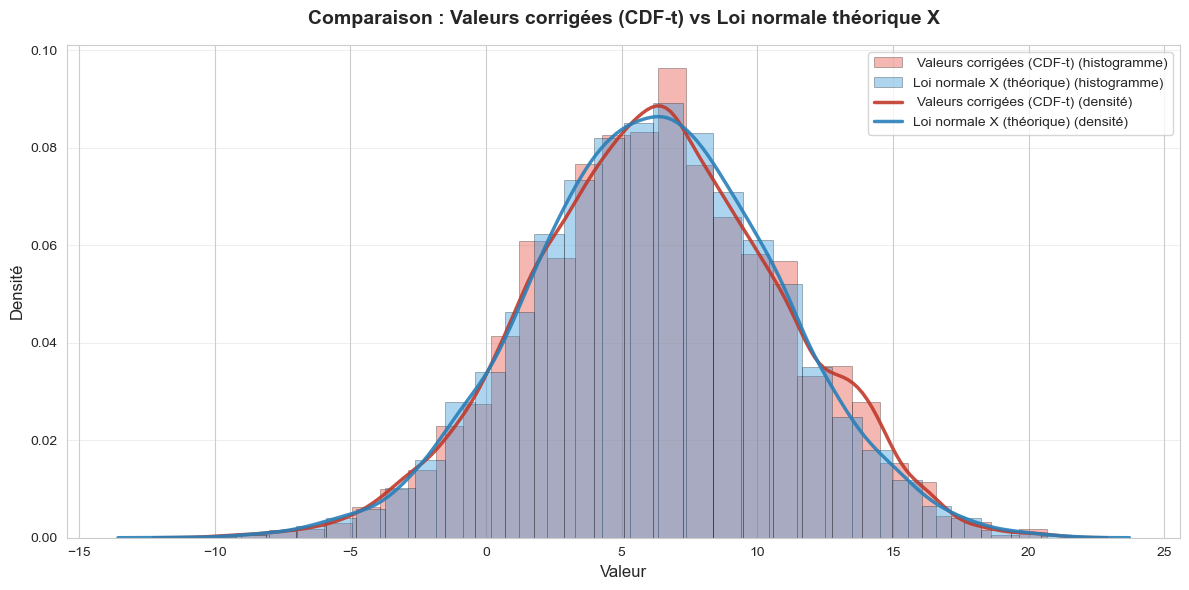

In [7]:
#Sélection mois et variable
CMIP6_hist = csv_to_pd_univ("data/CMIP6_historical.csv", 12, "tas", years = (1982,2014))
CMIP6_futur = csv_to_pd_univ("data/CMIP6_ssp585.csv", 12, "tas", years= (2015,2100))
obs_hist = csv_to_pd_univ("data/obs.csv", 12, "tas" , years = (1982,2014))


# ============================================================================
# ÉTAPE 1 : Estimer les paramètres des lois gaussiennes
# ============================================================================

# Extraire les données (supposant une seule colonne par DataFrame)
data_CMIP6_hist = CMIP6_hist.iloc[:, 0]
data_CMIP6_futur = CMIP6_futur.iloc[:, 0]
data_obs_hist = obs_hist.iloc[:, 0]

# Estimer les paramètres avec Maximum de Vraisemblance (MLE)
mu_CMIP6_hist, sigma_CMIP6_hist = stats.norm.fit(data_CMIP6_hist)
mu_CMIP6_futur, sigma_CMIP6_futur = stats.norm.fit(data_CMIP6_futur)
mu_obs_hist, sigma_obs_hist = stats.norm.fit(data_obs_hist)

print(f"Paramètres estimés (MLE) :")
print(f"CMIP6_hist : μ={mu_CMIP6_hist:.2f}, σ={sigma_CMIP6_hist:.2f}")
print(f"CMIP6_futur : μ={mu_CMIP6_futur:.2f}, σ={sigma_CMIP6_futur:.2f}")
print(f"obs_hist : μ={mu_obs_hist:.2f}, σ={sigma_obs_hist:.2f}")

# ============================================================================
# ÉTAPE 2 : Simuler 10000 valeurs pour chaque variable aléatoire
# ============================================================================

n_simulations = 10000

# Simuler depuis les lois gaussiennes estimées
sim_CMIP6_hist = np.random.normal(mu_CMIP6_hist, sigma_CMIP6_hist, n_simulations)
sim_CMIP6_futur = np.random.normal(mu_CMIP6_futur, sigma_CMIP6_futur, n_simulations)
sim_obs_hist = np.random.normal(mu_obs_hist, sigma_obs_hist, n_simulations)

# Créer les DataFrames
CMIP6_hist_norm = pd.DataFrame({'CMIP6_hist_sim': sim_CMIP6_hist})
CMIP6_futur_norm = pd.DataFrame({'CMIP6_futur_sim': sim_CMIP6_futur})
obs_hist_norm = pd.DataFrame({'obs_hist_sim': sim_obs_hist})

# ============================================================================
# ÉTAPE 3 : Appliquer la fonction cdf_t_univ
# ============================================================================

df_futur_sim, df_corrige = cdf_t_univ(CMIP6_hist_norm, obs_hist_norm, CMIP6_futur_norm)

# ============================================================================
# ÉTAPE 4 : Simuler la loi normale X avec les paramètres calculés
# ============================================================================

# Calculer les paramètres de X directement avec les paramètres estimés
mu_X = mu_CMIP6_futur + (mu_obs_hist - mu_CMIP6_hist) * (sigma_CMIP6_futur / sigma_CMIP6_hist)
sigma_X = sigma_obs_hist * (sigma_CMIP6_futur / sigma_CMIP6_hist)

print(f"\nParamètres de la loi X :")
print(f"μ_X = {mu_X:.2f}")
print(f"σ_X = {sigma_X:.2f}")

# Simuler X
sim_X = np.random.normal(mu_X, sigma_X, n_simulations)
df_X = pd.DataFrame({'X_theorique': sim_X})

# ============================================================================
# ÉTAPE 5 : Comparer les distributions avec plot_distributions
# ============================================================================

# Créer le tuple des DataFrames
dfs_tuple = (df_corrige, df_X)

# Créer le titre
titre = "Comparaison : Valeurs corrigées (CDF-t) vs Loi normale théorique X"

# Créer les labels
labels_tuple = ("Valeurs corrigées (CDF-t)", "Loi normale X (théorique)")

# Tracer les distributions
plot_distributions(dfs_tuple, titre, labels_tuple)



## Implémentation CDF-t multivariée

In [ ]:
"""
month = 1

common_columns = ['tas', 'uas', 'vas', 'rsds', 'rlds']

# Extraire les données pour le mois choisi
Y0 = extract_month_data("data/obs.csv", month, common_columns, years = (1982,2014))  # Observations
X0 = extract_month_data("data/CMIP6_historical.csv", month, common_columns, years = (1982, 2014) )  # Modèle passé
X1 = extract_month_data("data/CMIP6_ssp585.csv", month, common_columns, years = (2015,2100))  # Modèle futur


# Appliquer la correction MBCn
mbc = SBCK.MBCn()

# Calibration avec les 3 datasets
mbc.fit(Y0, X0, X1)

# Correction des valeurs futures
X1_corrected, _ = mbc.predict(X1, X0)

# Sauvegarder les résultats
df_corrected = pd.DataFrame(X1_corrected, columns=common_columns)

output_path = f'data/CMIP6_ssp585_corrected_month_{month}.csv'
df_corrected.to_csv(output_path, sep=';', index=False)
import ot # Bibliothèque Python Optimal Transport
from scipy.spatial.distance import cdist"""

Données extraites de data/obs.csv: 8184 lignes, 5 variables pour le mois 1 (1982-2014)
Données extraites de data/CMIP6_historical.csv: 1023 lignes, 5 variables pour le mois 1 (1982-2014)
Données extraites de data/CMIP6_ssp585.csv: 2666 lignes, 5 variables pour le mois 1 (2015-2100)


In [23]:
import ot # Bibliothèque Python Optimal Transport
from scipy.spatial.distance import cdist

mois_a_afficher = [6]  
vars_cols = ['tas', 'rlds', 'rsds', 'uas', 'vas']

def csv_to_pd_multi(filepath, mois, vars_list, years=None):
    """
    Charge un CSV et extrait PLUSIEURS variables pour un mois donné.
    Garde la date en index pour pouvoir reconstruire la série temporelle.
    """
    if years is not None and (not isinstance(years, tuple) or len(years) != 2):
        raise ValueError(f"years doit être un tuple de 2 éléments (année_début, année_fin)")
    
    # Lire le CSV
    df = pd.read_csv(filepath, sep=';', parse_dates=['date'])

    # Filtrer sur le mois
    df = df[df['date'].dt.month == mois]
    
    # Filtrer sur la période d'années
    if years is not None:
        year_start, year_end = years
        df = df[(df['date'].dt.year >= year_start) & (df['date'].dt.year <= year_end)]
    
    # Vérification
    if df.empty:
        raise ValueError(f"Aucune donnée trouvée pour le mois {mois} dans {filepath}")

    # On met la date en index pour ne pas la perdre
    df = df.set_index('date')
    
    # On sélectionne TOUTES les colonnes de la liste vars_list
    # Attention: il faut que toutes les colonnes existent dans le CSV
    try:
        df_final = df[vars_list].copy()
    except KeyError as e:
        raise KeyError(f"Une des variables demandées n'est pas dans le fichier: {e}")

    return df_final

def cdf_t_multidim(Obs_hist, Mod_hist, Mod_fut):
    """
    Correction de biais Multidimensionnelle par Transport Optimal (Barycentric Mapping + NN).
    """
    # Conversion en arrays
    Y0 = np.array(Obs_hist)
    X0 = np.array(Mod_hist)
    X1 = np.array(Mod_fut)
    
    # A. Transport Optimal entre Modèle Passé (X0) et Modèle Futur (X1)
    # calcule la "carte" qui transforme le passé en futur selon le modèle
    M = ot.dist(X0, X1, metric='sqeuclidean') # matrice de coût
    n0, n1 = len(X0), len(X1)
    a, b = np.ones(n0)/n0, np.ones(n1)/n1 # Poids uniformes
    
    # résolution du transport (EMD)
    gamma = ot.emd(a, b, M)
    
    # Projection barycentrique : Pour chaque point de X0, où atterrit-il en moyenne dans X1 ?
    # C'est notre transformation T apprise : T(X0)
    X0_transported = n0 * np.dot(gamma, X1)
    
    # B. Application aux Observations (Y0) par Plus Proche Voisin
    # "Pour chaque Y0, chercher le point le plus proche de X0"
    dists = cdist(Y0, X0, metric='euclidean')
    idx_nn = np.argmin(dists, axis=1) # Indices des voisins dans X0
    
    # On applique la transformation du voisin : Y1 = T(X0_voisin)
    Y1_corr = X0_transported[idx_nn]
    
    return Y1_corr




for i in range (1,13):

    #Sélection mois et variable
    CMIP6_hist = csv_to_pd_multi(path_CMIP6_hist, i, vars_cols, years = (1982,2014))
    CMIP6_futur = csv_to_pd_multi(path_CMIP6_fut, i, vars_cols, years= (2015,2022))
    obs_hist = csv_to_pd_multi(path_obs, i, vars_cols, years = (1982,2014))
    obs_futur = csv_to_pd_multi(path_obs, i, vars_cols, years = (2015,2022))

    # correction
    modele_futur_corrige  = cdf_t_multidim(obs_hist, CMIP6_hist,CMIP6_futur) 

    #Représentation graphique
    if i in mois_a_afficher:
        """ comparer distribution marginales pour chaque variable """

                      tas    rlds    rsds       uas       vas
date                                                         
2015-06-01 00:00:00  14.2  324.72    0.00  0.424264 -0.424264
2015-06-01 03:00:00  13.3  313.99    0.00  0.689440 -0.578509
2015-06-01 06:00:00  17.9  362.11   57.96  1.735832  1.508936
2015-06-01 09:00:00  21.7  369.61  412.59  2.753167  3.931930
2015-06-01 12:00:00  23.3  377.70  682.01  3.200000  5.542563 [[ 1.19334244e+01  3.60763860e+02  6.52150815e+01  1.40242939e+00
  -1.81545544e-01]
 [ 1.19334244e+01  3.60763860e+02  6.52150815e+01  1.40242939e+00
  -1.81545544e-01]
 [ 1.40751066e+01  3.61139638e+02  7.30080824e+01  6.48791255e-01
   1.79628278e+00]
 ...
 [ 1.25821504e+01  2.80751827e+02  3.69022330e+02 -1.89736704e-01
  -6.54235237e-01]
 [ 2.30563652e+01  3.63393333e+02  3.30501206e+02 -2.91919652e-01
   1.70208980e+00]
 [ 1.33565667e+01  3.58321967e+02  7.24148004e+01  6.07142840e-01
   2.87308602e+00]]
